In [1]:
# Cell 1: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT/'figures'/'figures_Markov'/'figures_BinaryModel'
RESULTS = PROJ_ROOT/'results'/'results_Markov'/'results_BinaryModel'

In [2]:
# Cell 2: globals settings

EPS = 0.49
N = 50000
Y = 20
SEED = 63

rng = np.random.default_rng(SEED)


In [3]:
# Cell 3: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

In [4]:
# cell 4: build empirical w/ log prod and transitions


df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())
working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)
working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)
working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]
is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)
working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["log_pubs_adj", "log_pubs_next"]).copy())

print("Rows in orig df:", len(working_df))
print("Rows w valid one-year trans:", len(working_df_fit))
print()
print(working_df_fit[["log_pubs_adj", "log_pubs_next", "log_delta"]].describe())

Rows in orig df: 54948
Rows w valid one-year trans: 34701

       log_pubs_adj  log_pubs_next     log_delta
count  34701.000000   34701.000000  34701.000000
mean       1.442084       1.448262      0.006178
std        1.131298       1.123265      1.057639
min       -0.713350      -0.713350     -5.028100
25%        0.924939       0.924939     -0.509761
50%        1.661082       1.661082     -0.026502
75%        2.251545       2.251545      0.523108
max        4.396630       4.396630      4.138016


In [5]:
# Cell 5: build binary states

df = working_df.copy()
df = df[df["CareerAge"].between(0, Y)].copy()

id_col = "dblp_id"
age_col = "CareerAge"
prod_col = "pubs_adj"

df["state"] = (df[prod_col] > 0).astype(int)

state_labels = {
    0: "No pubs",
    1: "Some pubs",}

state_order = [0, 1]
n_states = len(state_order)

print(df[[id_col, age_col, prod_col, "state"]].head())
print()
print("State counts:")
print(df["state"].map(state_labels).value_counts())


                        dblp_id  CareerAge   pubs_adj  state
3  =Ccedil=etintemel:Ugur2001.0          0   5.209137      1
4  =Ccedil=etintemel:Ugur2001.0          1   6.691238      1
5  =Ccedil=etintemel:Ugur2001.0          2  12.901876      1
6  =Ccedil=etintemel:Ugur2001.0          3   4.667694      1
7  =Ccedil=etintemel:Ugur2001.0          4  12.016541      1

State counts:
state
Some pubs    31549
No pubs       5577
Name: count, dtype: int64


In [6]:
# Cell 6: trans counts n probs

df = df.sort_values([id_col, age_col]).copy()

df["next_state"] = df.groupby(id_col)["state"].shift(-1)
df["next_age"] = df.groupby(id_col)[age_col].shift(-1)

trans = df[df["next_age"] == df[age_col] + 1].copy()

trans["state"] = trans["state"].astype(int)
trans["next_state"] = trans["next_state"].astype(int)

def transition_counts_and_probs(g):
    counts = pd.crosstab(g["state"], g["next_state"])
    counts = counts.reindex(index=state_order, columns=state_order, fill_value=0)
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    return counts, probs

global_counts, global_P = transition_counts_and_probs(trans)

print("Transition counts:")
print(global_counts.rename(index=state_labels, columns=state_labels))

print("\nTransition probabilities:")
print(global_P.rename(index=state_labels, columns=state_labels).round(3))


Transition counts:
next_state  No pubs  Some pubs
state                         
No pubs        2318       3061
Some pubs      2823      26499

Transition probabilities:
next_state  No pubs  Some pubs
state                         
No pubs       0.431      0.569
Some pubs     0.096      0.904


In [7]:
# Cell 7: stagewise P matrices

stage_order = ["0-4", "5-7", "8-13", "14-20"]

def assign_career_stage(year):
    if 0 <= year <= 4:
        return "0-4"
    elif 5 <= year <= 7:
        return "5-7"
    elif 8 <= year <= 13:
        return "8-13"
    elif 14 <= year <= 20:
        return "14-20"
    else:
        return np.nan

trans["stage"] = trans[age_col].apply(assign_career_stage)

stage_counts = {}
stage_P = {}

for stage in stage_order:
    g = trans[trans["stage"] == stage]

    counts, probs = transition_counts_and_probs(g)

    stage_counts[stage] = counts
    stage_P[stage] = probs

    print(f"{stage} counts:")
    print(counts.rename(index=state_labels, columns=state_labels))

    print(f"{stage} P matrix:")
    print(probs.rename(index=state_labels, columns=state_labels).round(3))
    print()

0-4 counts:
next_state  No pubs  Some pubs
state                         
No pubs         624       1086
Some pubs       910       8298
0-4 P matrix:
next_state  No pubs  Some pubs
state                         
No pubs       0.365      0.635
Some pubs     0.099      0.901

5-7 counts:
next_state  No pubs  Some pubs
state                         
No pubs         324        449
Some pubs       469       5159
5-7 P matrix:
next_state  No pubs  Some pubs
state                         
No pubs       0.419      0.581
Some pubs     0.083      0.917

8-13 counts:
next_state  No pubs  Some pubs
state                         
No pubs         730        846
Some pubs       836       8084
8-13 P matrix:
next_state  No pubs  Some pubs
state                         
No pubs       0.463      0.537
Some pubs     0.094      0.906

14-20 counts:
next_state  No pubs  Some pubs
state                         
No pubs         640        680
Some pubs       608       4958
14-20 P matrix:
next_state  No pubs

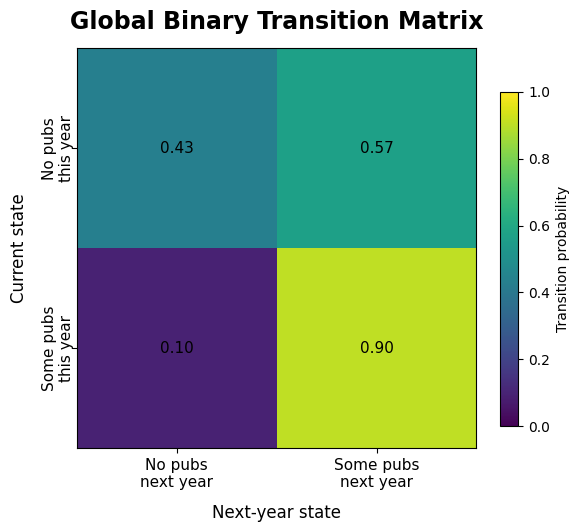

In [8]:
# Cell 8: global transition 

def plot_transition_heatmap(P, title):
    fig, ax = plt.subplots(figsize=(6.2, 5.4))

    mat = P.values.astype(float)

    im = ax.imshow(mat, vmin=0, vmax=1, aspect="equal")

    ax.set_xticks(range(n_states))
    ax.set_yticks(range(n_states))

    ax.set_xticklabels(
        [f"{state_labels[s]}\nnext year" for s in state_order],
        fontsize=11
    )

    ax.set_yticklabels(
        [f"{state_labels[s]}\nthis year" for s in state_order],
        fontsize=11,
        rotation=90,
        va="center",
        ha="center",
        rotation_mode="anchor")

    ax.tick_params(axis="y", pad=10)
    for label in ax.get_yticklabels():
        x, y = label.get_position()
        label.set_y(y - 0.04)

    for i in range(n_states):
        for j in range(n_states):
            val = mat[i, j]
            label = "—" if np.isnan(val) else f"{val:.2f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=11)

    ax.set_title(title, fontsize=17, fontweight="bold", pad=14)
    ax.set_xlabel("Next-year state", fontsize=12, labelpad=10)
    ax.set_ylabel("Current state", fontsize=12, labelpad=10)

    fig.subplots_adjust(left=0.18, right=0.84, top=0.88, bottom=0.14)

    cbar_ax = fig.add_axes([0.87, 0.18, 0.03, 0.62])
    fig.colorbar(im, cax=cbar_ax, label="Transition probability")

    plt.savefig(FIGURES / "binaryModel_globalTransMatrix.png", dpi=300, bbox_inches="tight")

    plt.show()


plot_transition_heatmap(global_P, "Global Binary Transition Matrix")


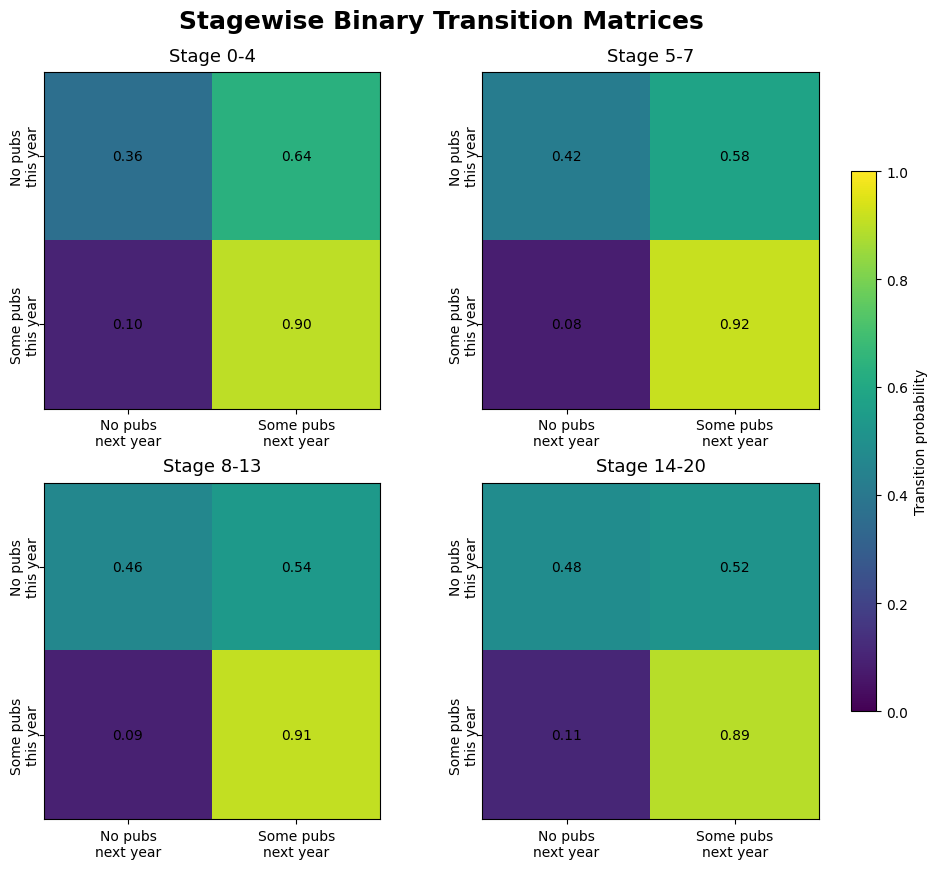

In [9]:
# Cell 9: trans heatmaps

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 9),
    gridspec_kw={"wspace": 0.15, "hspace": 0.22})

axes_flat = axes.ravel()

for ax, stage in zip(axes_flat, stage_order):
    P_stage = stage_P[stage]
    mat = P_stage.values.astype(float)

    im = ax.imshow(mat, vmin=0, vmax=1, aspect="equal")

    ax.set_title(f"Stage {stage}", fontsize=13, pad=8)

    ax.set_xticks(range(n_states))
    ax.set_yticks(range(n_states))

    ax.set_xticklabels(
        [f"{state_labels[s]}\nnext year" for s in state_order],
        fontsize=10
    )

    ax.set_yticklabels(
        [f"{state_labels[s]}\nthis year" for s in state_order],
        fontsize=10,
        rotation=90,
        va="center",
        ha="center",
        rotation_mode="anchor"
    )

    ax.tick_params(axis="y", pad=10)

    for label in ax.get_yticklabels():
        x, y = label.get_position()
        label.set_y(y - 1)

    for i in range(n_states):
        for j in range(n_states):
            val = mat[i, j]
            label = "—" if np.isnan(val) else f"{val:.2f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=10)

for ax in axes_flat[len(stage_order):]:
    ax.axis("off")

fig.suptitle(
    "Stagewise Binary Transition Matrices",
    fontsize=18,
    fontweight="bold",
    x=0.5,
    y=0.98
)

fig.subplots_adjust(
    left=0.08,
    right=0.90,
    top=0.91,
    bottom=0.08,
    wspace=0.12,
    hspace=0.28)

cbar_ax = fig.add_axes([0.91, 0.20, 0.025, 0.60])
fig.colorbar(im, cax=cbar_ax, label="Transition probability")

plt.savefig(FIGURES / "binaryModel_stageTransMatrices.png", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
# Cell 10: stagewise binary transition summary

summary_rows = []

for stage in stage_order:
    P_stage = stage_P[stage]

    summary_rows.append({
        "stage": stage,
        "P_nothing_to_nothing": P_stage.loc[0, 0],
        "P_nothing_to_something": P_stage.loc[0, 1],
        "P_something_to_nothing": P_stage.loc[1, 0],
        "P_something_to_something": P_stage.loc[1, 1],})

stage_transition_summary = pd.DataFrame(summary_rows).round(3)

display(stage_transition_summary)


,stage,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0-4,0.365,0.635,0.099,0.901
1,5-7,0.419,0.581,0.083,0.917
2,8-13,0.463,0.537,0.094,0.906
3,14-20,0.485,0.515,0.109,0.891


In [11]:
out_path = RESULTS / "binaryModel.csv"
stage_transition_summary.to_csv(out_path, index=False)